# Balancing classes with `LanguageModelOverSampler`

`LanguageModelOverSampler` implements the imbalanced-learn sampler API (`fit_resample`). For each
under-represented class $c$ it conditions on the label and generates the features,

$$ x^{\text{new}} \sim p\!\left(\text{features} \mid \text{class} = c\right), $$

appending rows until the classes are balanced. Unlike SMOTE, which interpolates between neighbouring
minority points and needs a numeric vector space, it samples from the learned conditional, so it
works directly on mixed and categorical tables.

To check it, balanced Iris is made imbalanced by dropping most of one class, oversampled back, and
the synthetic rows are compared with the real rows of that class.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

from sklm import LanguageModelOverSampler, TrainingConfig, EvalConfig, GenerationConfig

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
MINORITY = 2  # the Iris class to under-sample, then regenerate
KEEP = 20  # real rows of the minority class left for training

## Creating the imbalance

In [2]:
iris = load_iris(as_frame=True)
X_full = iris.data.set_axis(
    ["sepal_length", "sepal_width", "petal_length", "petal_width"], axis=1
)
y_full = iris.target.to_numpy()

rng = np.random.default_rng(SEED)
minority_idx = np.where(y_full == MINORITY)[0]
drop = rng.choice(minority_idx, size=len(minority_idx) - KEEP, replace=False)
keep_mask = np.ones(len(y_full), dtype=bool)
keep_mask[drop] = False
X = X_full[keep_mask].reset_index(drop=True)
y = y_full[keep_mask]
pd.Series(y).value_counts().sort_index()

0    50
1    50
2    20
Name: count, dtype: int64

## Resampling

`fit_resample` fine-tunes once, then generates minority rows until the classes are balanced.
`X_res` is the original data with the synthetic rows appended.

In [3]:
X_res, y_res = LanguageModelOverSampler(
    backend="mlx",
    model="mlx-community/distilgpt2",
    training=TrainingConfig(
        numeric_noise=0.1,
        evaluation=None,
        epochs=70,
        batch_size=8
    ),
    generation=GenerationConfig(temperature=0.4),
    random_state=SEED,
).fit_resample(X, y)
print(f"rows: {len(X)} -> {len(X_res)} ({len(X_res) - len(X)} synthesized)")

/Users/gabfssilva/workspace/scikit-lm/.venv/lib/python3.12/site-packages/imblearn/base.py:107: RuntimeWarning: target_loss_weight has no effect on the oversampler: it conditions generation on the label and produces the features, so there is no fixed target column. Ignoring.
  output = self._fit_resample(X, y, **params)


HTML(value='')

rows: 120 -> 150 (30 synthesized)


## Class distribution: before vs. after

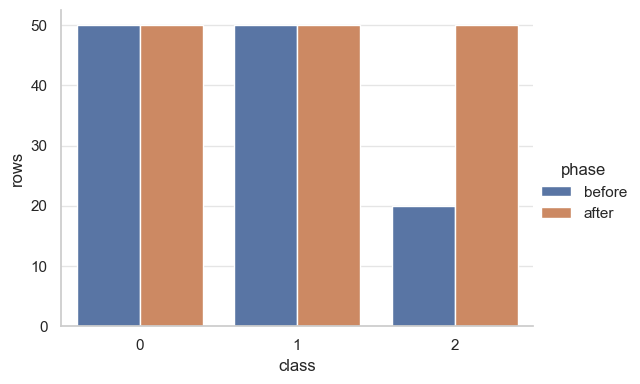

In [4]:
counts = (
    pd.DataFrame({
        "before": pd.Series(y).value_counts().sort_index(),
        "after": pd.Series(y_res).value_counts().sort_index(),
    })
    .reset_index(names="class")
    .melt(id_vars="class", var_name="phase", value_name="n")
)

g = sns.catplot(counts, kind="bar", x="class", y="n", hue="phase", height=4, aspect=1.4)
g.set_axis_labels("class", "rows")
plt.show()

## Real vs. synthetic

Per-feature moments first: the synthetic mean and standard deviation should be close to the real
minority class's.

In [9]:
synth = X_res.iloc[len(X):].reset_index(drop=True)
real = X_full[y_full == MINORITY]
pd.DataFrame({
    "real_mean": real.mean(),
    "synth_mean": synth.mean(),
    "real_std": real.std(),
    "synth_std": synth.std(),
    "real_min": real.min(),
    "synth_min": synth.min(),
    "real_max": real.max(),
    "synth_max": synth.max()
}).round(2)

,real_mean,synth_mean,real_std,synth_std,real_min,synth_min,real_max,synth_max
sepal_length,6.59,6.44,0.64,0.35,4.9,5.7,7.9,6.9
sepal_width,2.97,3.10,0.32,0.27,2.2,2.6,3.8,3.4
petal_length,5.55,5.50,0.55,0.38,4.5,4.3,6.9,5.9
petal_width,2.03,2.19,0.27,0.31,1.4,1.5,2.5,2.5


Then the joint structure: the synthetic rows should overlap the real rows of the minority class,
of which the model only saw `KEEP` examples.

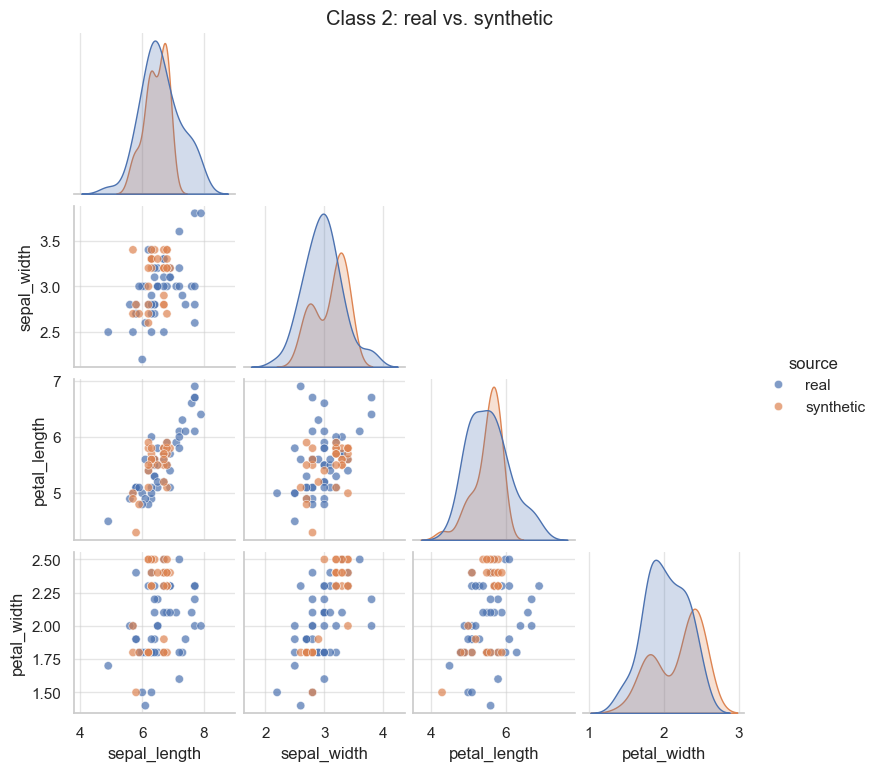

In [6]:
compare = pd.concat(
    [real.assign(source="real"), synth.assign(source="synthetic")], ignore_index=True
)
g = sns.pairplot(compare, hue="source", corner=True, height=1.9, plot_kws={"alpha": 0.7})
g.figure.suptitle(f"Class {MINORITY}: real vs. synthetic", y=1.01)
plt.show()